In [21]:
import os
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import keras
from keras.utils import load_img, img_to_array, to_categorical
from keras import layers, models
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping
import keras_tuner as kt

** Data Understanding **

In [2]:
# Dataset path
dataset_path = "fruit_dataset/"
for dirpath, dirnames, filenames in os.walk(dataset_path):
    print(f"{len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

15 directories and 0 images in 'fruit_dataset/'.
0 directories and 5024 images in 'fruit_dataset/Apple'.
0 directories and 3027 images in 'fruit_dataset/Banana'.
0 directories and 2080 images in 'fruit_dataset/Carambola'.
0 directories and 4008 images in 'fruit_dataset/Guava'.
0 directories and 4173 images in 'fruit_dataset/Kiwi'.
0 directories and 4154 images in 'fruit_dataset/Mango'.
0 directories and 2078 images in 'fruit_dataset/muskmelon'.
0 directories and 3012 images in 'fruit_dataset/Orange'.
0 directories and 2629 images in 'fruit_dataset/Peach'.
0 directories and 3012 images in 'fruit_dataset/Pear'.
0 directories and 2072 images in 'fruit_dataset/Persimmon'.
0 directories and 2501 images in 'fruit_dataset/Pitaya'.
0 directories and 2298 images in 'fruit_dataset/Plum'.
0 directories and 2167 images in 'fruit_dataset/Pomegranate'.
0 directories and 2171 images in 'fruit_dataset/Tomatoes'.


In [3]:
# Show class names
data_dir = pathlib.Path(dataset_path)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['Apple' 'Banana' 'Carambola' 'Guava' 'Kiwi' 'Mango' 'Orange' 'Peach'
 'Pear' 'Persimmon' 'Pitaya' 'Plum' 'Pomegranate' 'Tomatoes' 'muskmelon']


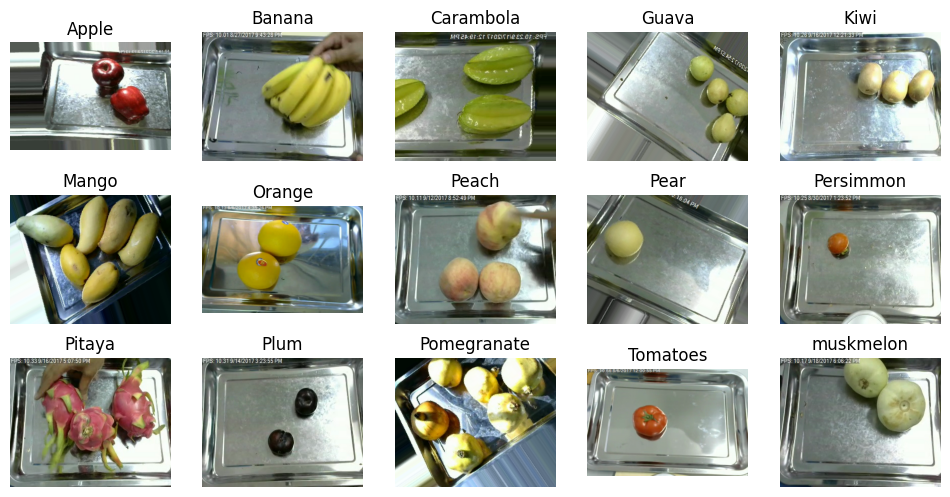

In [4]:
# Plot a grid of images from train dataset
def view_random_image(target_dir, target_class):
  target_folder = target_dir + target_class
  random_image = random.sample(os.listdir(target_folder), 100)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  return img

# View a random image from train dataset for all classes
plt.figure(figsize=(12,6))
for i in range(15):
    plt.subplot(3,5,i+1)
    img = view_random_image(target_dir=dataset_path,
                            target_class=class_names[i])

In [5]:
# Prepare Pandas DataFrame
data_obj = {'path': [], 'filename': [], 'label': []}
for dirpath, dirnames, filenames in os.walk(dataset_path):
    for f in filenames:
        full_path = os.path.join(dirpath, f)
        label = os.path.basename(os.path.dirname(full_path))
        data_obj['path'].append(dirpath)
        data_obj['filename'].append(f)
        data_obj['label'].append(label)

data_df = pd.DataFrame(data_obj)
data_df.sample(n=10)

,path,filename,label
30312,fruit_dataset/Pear,Pear 1112.png,Pear
7757,fruit_dataset/Banana,Banana0734.png,Banana
32981,fruit_dataset/Pear,pear_0_7655.png,Pear
39823,fruit_dataset/Plum,PlumÒÇé779.png,Plum
3179,fruit_dataset/Apple,Apple 03860.png,Apple
31531,fruit_dataset/Pear,Pear 230.png,Pear
34931,fruit_dataset/Persimmon,Persimmon695.png,Persimmon
26698,fruit_dataset/Orange,Orange002938.png,Orange
10819,fruit_dataset/Guava,Guava01618.png,Guava
1513,fruit_dataset/Apple,Apple 02360.png,Apple


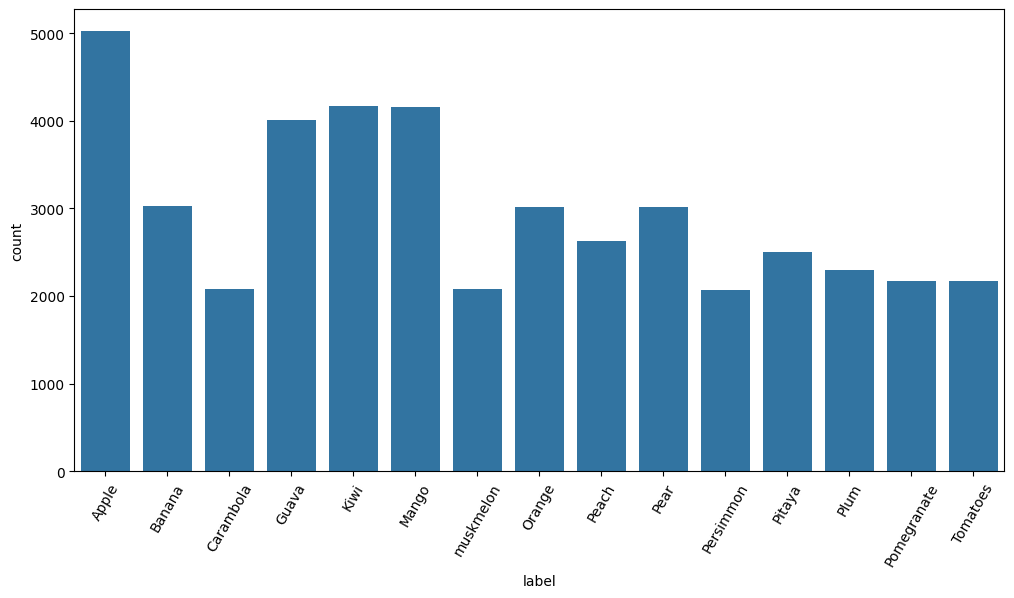

In [6]:
# Plot the number of images of each classes
plt.figure(figsize=(12,6))
sns_cntplot = sns.countplot(x='label', data=data_df)
plt.xticks(rotation=60)
plt.show()

** Data Preparation **

In [7]:
# Read images and create numpy data array
images = []
label = [] 

for _, d in data_df.iterrows():
    img = load_img(os.path.join(d['path'], d['filename']), target_size=(150,150))
    images.append(img_to_array(img))
    label.append(d['label'])

images = np.array(images)
labels = np.array(label)
print(f"Data images shape: {images.shape} and label shape: {labels.shape}")

Data images shape: (44406, 150, 150, 3) and label shape: (44406,)


In [8]:
# One-hot encoding
class_indices = dict(zip(class_names, range(len(class_names))))
labels_encoded = list(map(class_indices.get, labels))
label_categorical = to_categorical(labels_encoded, num_classes=len(class_names))

In [9]:
# Data splitting
train_im, val_test_im, train_lab, val_test_lab = train_test_split(
    images,
    label_categorical,
    test_size = 0.3,
    stratify=label_categorical,
    random_state = 100,
    shuffle = True
)

valid_im, test_im, valid_lab, test_lab = train_test_split(
    val_test_im,
    val_test_lab,
    test_size = 0.5,
    stratify = val_test_lab,
    random_state = 100,
    shuffle = True
)

In [10]:
# Data shape
print ("Train data shape: ", train_im.shape)
print ("Train label shape: ", train_lab.shape)
print ('Validation data shape: ', valid_im.shape)
print ("Validation label shape: ", valid_lab.shape)
print ('Test data shape: ', test_im.shape)
print ("Test label shape: ", test_lab.shape)

Train data shape:  (31084, 150, 150, 3)
Train label shape:  (31084, 15)
Validation data shape:  (6661, 150, 150, 3)
Validation label shape:  (6661, 15)
Test data shape:  (6661, 150, 150, 3)
Test label shape:  (6661, 15)


In [11]:
training_data = tf.data.Dataset.from_tensor_slices((train_im, train_lab))
validation_data = tf.data.Dataset.from_tensor_slices((valid_im, valid_lab))
testing_data = tf.data.Dataset.from_tensor_slices((test_im, test_lab))

In [12]:
# Data Pipeline, Normalization and Prefetching
rescale_data = Sequential([
    layers.Rescaling(1/255)
])
batch_size = 128
autotune = tf.data.AUTOTUNE

def prepare(ds, shuffle=False):
    ds = ds.map(lambda x, y: (rescale_data(x), y), num_parallel_calls=autotune)
    
    if shuffle:
        ds = ds.shuffle(1000)
    
    # batch data
    ds = ds.batch(batch_size)
    
    # Use buffered prefetching on all datasets
    return ds.prefetch(buffer_size=autotune)

train_ds = prepare(training_data, shuffle=True)
val_ds = prepare(validation_data)
test_ds = prepare(testing_data)

** Model Building (CNN) **

In [13]:
model = Sequential()

model.add(Conv2D(16, (3,3), activation='relu', input_shape=(150,150,3), padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(len(class_names), activation='softmax'))

model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

model.summary()

c:\Users\zhenc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,680,303 (10.22 MB)

 Trainable params: 2,680,079 (10.22 MB)

 Non-trainable params: 224 (896.00 B)

In [14]:
#Early stopping
early_stopping = EarlyStopping(
    patience = 10,
    restore_best_weights = True
)

# Model training
history = model.fit(
    train_ds,
    epochs = 30,
    validation_data = val_ds,
    callbacks = early_stopping
)

Epoch 1/30


243/243 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.6305 - loss: 1.1759 - val_accuracy: 0.2138 - val_loss: 7.3773
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.8520 - loss: 0.4141 - val_accuracy: 0.7215 - val_loss: 1.1207
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 241s 991ms/step - accuracy: 0.9046 - loss: 0.2677 - val_accuracy: 0.8934 - val_loss: 0.4165
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.9359 - loss: 0.1783 - val_accuracy: 0.8617 - val_loss: 0.6730
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 240s 987ms/step - accuracy: 0.9517 - loss: 0.1448 - val_accuracy: 0.9101 - val_loss: 0.3403
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 239s 983ms/step - accuracy: 0.9620 - loss: 0.1125 - val_accuracy: 0.9533 - val_loss: 0.1637
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 239s 984ms/step - accuracy: 0.9693 - loss: 0.0918 - val_accuracy: 0.8225 - val_loss: 1.0080
Epoch 8/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 237s 976ms/step - accuracy: 0.9709 - loss: 0.0859 - val_

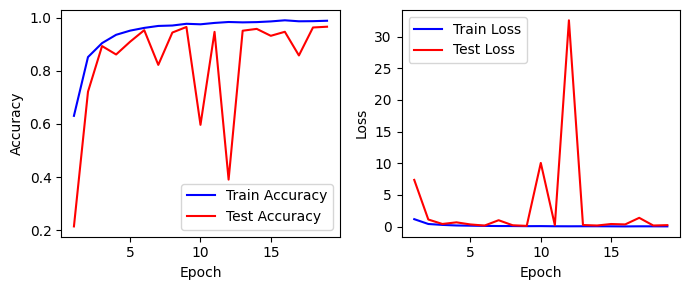

In [15]:
# Model history plotting
acc2 = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss2 = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc2)+1)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].plot(epochs, acc2,'b',label='Train Accuracy')
axes[0].plot(epochs, val_acc,'r',label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, loss2,'b',label='Train Loss')
axes[1].plot(epochs, val_loss,'r',label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

plt.show()

** Model Tuning **

In [18]:
def build_model(hp):
    model = Sequential()

    model.add(Conv2D(
        filters=hp.Choice('filters_1', [16,32]),
        kernel_size=(3,3),
        activation='relu',
        input_shape=(150,150,3),
        padding='same'
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(
        filters=hp.Choice('filters_2', [32,64]),
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(
        filters=hp.Choice('filters_3', [64,128]),
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(
        units=hp.Choice('dense_units', [128, 256]),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1)))

    # Output layer
    model.add(Dense(len(class_names), activation='softmax'))

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Random Search tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='cnn_tuning'
)

# Search for best parameters
tuner.search(train_ds, epochs=5, validation_data=val_ds)

# Get best model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 5 Complete [00h 33m 20s]
val_accuracy: 0.9322924613952637

Best val_accuracy So Far: 0.9677225351333618
Total elapsed time: 03h 13m 00s


c:\Users\zhenc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,668,847 (40.70 MB)

 Trainable params: 10,668,463 (40.70 MB)

 Non-trainable params: 384 (1.50 KB)

In [19]:
# Best model training
history = best_model.fit(
    train_ds,
    epochs = 30,
    validation_data = val_ds,
    callbacks = early_stopping
)

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 574s 2s/step - accuracy: 0.9730 - loss: 0.0798 - val_accuracy: 0.9707 - val_loss: 0.0821
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.9803 - loss: 0.0569 - val_accuracy: 0.9647 - val_loss: 0.1037
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - accuracy: 0.9836 - loss: 0.0498 - val_accuracy: 0.9713 - val_loss: 0.0828
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - accuracy: 0.9875 - loss: 0.0360 - val_accuracy: 0.9724 - val_loss: 0.0827
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.9890 - loss: 0.0327 - val_accuracy: 0.9766 - val_loss: 0.0683
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - accuracy: 0.9901 - loss: 0.0295 - val_accuracy: 0.9776 - val_loss: 0.0680
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.9919 - loss: 0.0241 - val_accuracy: 0.9772 - val_loss: 0.0676
Epoch 8/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 502s 2s/step - accuracy: 0.9916 - loss: 0.0246 - val_accu

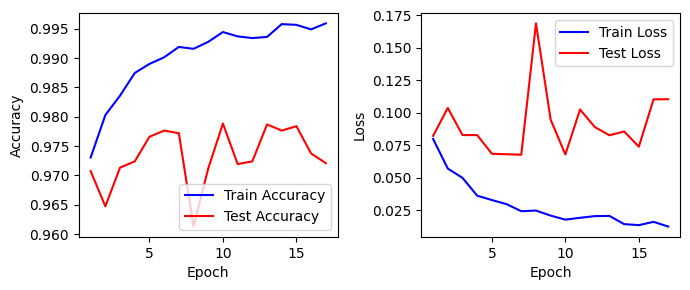

In [20]:
# Tuned best model history plotting
acc2 = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss2 = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc2)+1)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].plot(epochs, acc2,'b',label='Train Accuracy')
axes[0].plot(epochs, val_acc,'r',label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, loss2,'b',label='Train Loss')
axes[1].plot(epochs, val_loss,'r',label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

plt.show()

** Model Evaluation **

In [22]:
# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 446ms/step - accuracy: 0.9793 - loss: 0.0667
Test Loss: 0.0667
Test Accuracy: 0.9793


In [23]:
# Get predictions
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds])

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 288ms/step
Confusion Matrix:
[[722   0   0   3   1   0   0   5   4   0   0   0   0   1  18]
 [  0 435   0   1   2   2   0   0   3   0   0   0  11   0   0]
 [  0   0 311   1   0   0   0   0   0   0   0   0   0   0   0]
 [  8   7   0 585   1   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 625   0   0   0   1   0   0   0   0   0   0]
 [  1   4   1   0   4 608   2   0   2   0   0   0   1   0   0]
 [  0   0   0   0   0   0 449   0   0   3   0   0   0   0   0]
 [  3   0   0   0   1   0   0 390   1   0   0   0   0   0   0]
 [  6   0   0   0   1   1   0   0 443   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0 311   0   0   0   0   0]
 [  1   0   0   0   0   0   0   0   0   0 373   0   0   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0 344   0   0   0]
 [  5   3   0   0   2   3   1   0   0   1   0   0 310   0   0]
 [  6   0   0   0   0   0   0   0   0   0   0   0   0 319   0]
 [ 13   0   0   0   0   0   0   0   1   0   0   0   0   0 

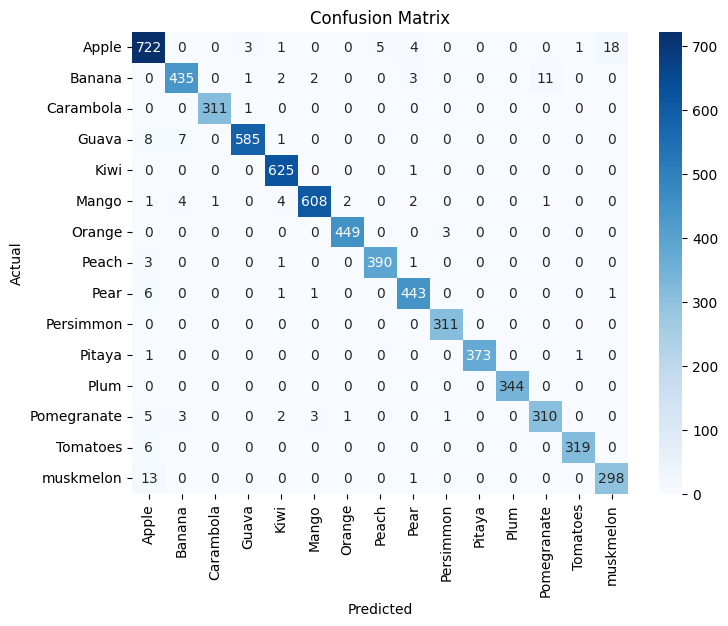

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()